# SafeSplit Walkthrough

This notebook is the explanatory layer for the SafeSplit midterm reproduction.

It imports the real project modules instead of re-implementing the system in notebook cells. The goal is to connect the paper's ideas to the codebase step by step:

- load CIFAR-10
- partition clients with the main-label non-IID split
- build the split model as `head -> backbone -> tail`
- inspect one clean split-learning step
- inspect one poisoned client step
- compute Main Task Accuracy (MA) and Backdoor Accuracy (BA)
- inspect SafeSplit checkpoint history
- visualize DCT and rotational scores
- show rollback selection
- run one small end-to-end example

The small runs here are intentionally lightweight so the notebook stays readable and interactive.

In [2]:
from __future__ import annotations

import random
from collections import Counter

import numpy as np
import torch
from IPython.display import display
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid
from notebooks.plt_utils import plt, HAS_MPL


import config as cfg
from data import (
    PixelTriggerAttack,
    PoisonedDataset,
    SemanticTriggerAttack,
    build_client_subsets,
    load_datasets,
    partition_data,
)
from data.backdoor import MEAN, STD
from defense import SafeSplitDefense
from defense.safesplit import dct_low_frequency, flatten_state_dict, rotational_signature, smallest_majority_sum
from evaluate import evaluate_backdoor, evaluate_model
from main import build_experiment_request, run_experiment
from models import get_split_model
from training import SplitLearningTrainer

NOTEBOOK_SEED = 7
random.seed(NOTEBOOK_SEED)
np.random.seed(NOTEBOOK_SEED)
torch.manual_seed(NOTEBOOK_SEED)

device = cfg.resolve_device(None)
print(f"Notebook device: {device}")
print(f"Matplotlib available: {HAS_MPL}")


def unnormalize(image: torch.Tensor) -> torch.Tensor:
    return ((image.detach().cpu() * STD) + MEAN).clamp(0.0, 1.0)


def summarize_counter(counter: Counter, class_names: list[str]) -> dict[str, int]:
    return {class_names[idx]: int(counter.get(idx, 0)) for idx in range(len(class_names)) if counter.get(idx, 0) > 0}


def show_rows(rows: list[dict], max_rows: int = 10) -> None:
    rows = rows[:max_rows]
    if not rows:
        print("No rows to display.")
        return
    headers = list(rows[0].keys())
    widths = {header: max(len(str(header)), *(len(str(row.get(header, ""))) for row in rows)) for header in headers}
    header_line = " | ".join(f"{header:<{widths[header]}}" for header in headers)
    sep_line = "-+-".join("-" * widths[header] for header in headers)
    print(header_line)
    print(sep_line)
    for row in rows:
        print(" | ".join(f"{str(row.get(header, '')):<{widths[header]}}" for header in headers))


def result_to_row(result: dict[str, object]) -> dict[str, object]:
    run_cfg = result["config"]
    return {
        "preset": run_cfg["preset"],
        "arch": run_cfg["arch"],
        "defense": run_cfg["defense"],
        "backdoor": run_cfg["backdoor"],
        "iid_rate": run_cfg["iid_rate"],
        "rounds": run_cfg["num_rounds"],
        "clients": run_cfg["num_clients"],
        "malicious": run_cfg["num_malicious"],
        "final_MA": round(float(result["final_MA"]), 4),
        "final_BA": round(float(result["final_BA"]), 4),
        "results_path": result.get("results_path"),
    }


def plot_metric_summary(rows: list[dict], title: str) -> None:    
    labels = [f"{row['defense']}\n{row['backdoor']}\nIID={row['iid_rate']}" for row in rows]
    ma_values = [row["final_MA"] for row in rows]
    ba_values = [row["final_BA"] for row in rows]
    x = np.arange(len(labels))
    width = 0.38
    plt.figure(figsize=(max(8, len(labels) * 1.4), 4.5))
    plt.bar(x - width / 2, ma_values, width, label="MA")
    plt.bar(x + width / 2, ba_values, width, label="BA")
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


Notebook device: cuda
Matplotlib available: True


## Load CIFAR-10

The project code uses the same dataset-loading path as the experiment runner. This cell downloads or reuses the cached CIFAR-10 dataset, prints the basic sizes, and shows a small sample grid.

100%|██████████| 170M/170M [00:10<00:00, 16.6MB/s] 


Extracting D:\Documents\UniBern\Material\Distributed Deep Learning Systems\project\SafeSplit_Distributed_DL\data_cache\cifar-10-python.tar.gz to D:\Documents\UniBern\Material\Distributed Deep Learning Systems\project\SafeSplit_Distributed_DL\data_cache
Files already downloaded and verified
Train size: 50000
Test size:  10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


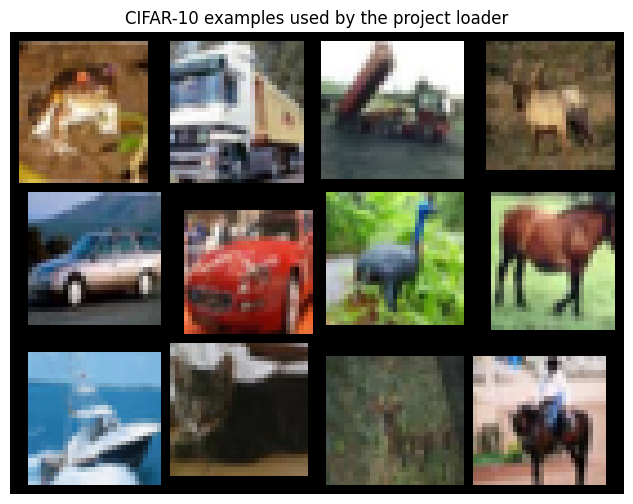

In [3]:
train_dataset, test_dataset = load_datasets(cfg.DATA_DIR)
class_names = list(train_dataset.classes)

print(f"Train size: {len(train_dataset)}")
print(f"Test size:  {len(test_dataset)}")
print("Classes:", class_names)

sample_items = [train_dataset[i][0] for i in range(12)]
sample_grid = make_grid(torch.stack([unnormalize(image) for image in sample_items]), nrow=4)

plt.figure(figsize=(8, 6))
plt.imshow(sample_grid.permute(1, 2, 0))
plt.title("CIFAR-10 examples used by the project loader")
plt.axis("off")
plt.show()

print("Install matplotlib in the notebook environment to render the image grid.")


## Partition Clients With The Main-Label Non-IID Split

The paper and proposal focus on multiple clients with non-IID data. The implementation uses a simple main-label strategy: each client receives a dominant label plus an IID remainder controlled by the `iid_rate` parameter.

client | samples | dominant_label | dominant_count | label_mix                                                                                                                   
-------+---------+----------------+----------------+-----------------------------------------------------------------------------------------------------------------------------
0      | 128     | truck          | 59             | {'airplane': 11, 'automobile': 11, 'bird': 6, 'cat': 4, 'deer': 5, 'dog': 11, 'frog': 8, 'horse': 4, 'ship': 9, 'truck': 59}
1      | 128     | airplane       | 60             | {'airplane': 60, 'automobile': 7, 'bird': 5, 'cat': 5, 'deer': 10, 'dog': 8, 'frog': 9, 'horse': 9, 'ship': 8, 'truck': 7}  
2      | 128     | airplane       | 61             | {'airplane': 61, 'automobile': 9, 'bird': 4, 'cat': 8, 'deer': 5, 'dog': 8, 'frog': 10, 'horse': 8, 'ship': 6, 'truck': 9}  
3      | 128     | truck          | 58             | {'airplane': 5, 'automobile': 4, 'bird': 7, 'cat': 9, 'de

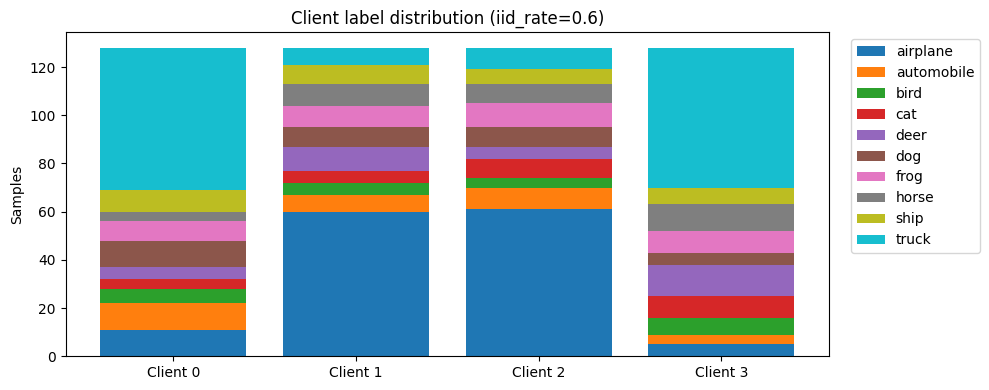

In [4]:
note_num_clients = 4
note_iid_rate = 0.6
note_max_samples = 128

partitions = partition_data(
    train_dataset,
    num_clients=note_num_clients,
    iid_rate=note_iid_rate,
    num_classes=cfg.NUM_CLASSES,
    seed=NOTEBOOK_SEED,
    max_samples_per_client=note_max_samples,
)
client_subsets = build_client_subsets(train_dataset, partitions)

distribution_rows = []
distribution_matrix = []
for client_id, subset in enumerate(client_subsets):
    labels = [int(train_dataset.targets[idx]) for idx in subset.indices]
    counts = Counter(labels)
    top_label, top_count = counts.most_common(1)[0]
    distribution_rows.append(
        {
            "client": client_id,
            "samples": len(subset),
            "dominant_label": class_names[top_label],
            "dominant_count": top_count,
            "label_mix": summarize_counter(counts, class_names),
        }
    )
    distribution_matrix.append([counts.get(label_idx, 0) for label_idx in range(cfg.NUM_CLASSES)])

show_rows(distribution_rows, max_rows=note_num_clients)

matrix = np.asarray(distribution_matrix)
plt.figure(figsize=(10, 4))
bottom = np.zeros(note_num_clients)
for class_idx, class_name in enumerate(class_names):
    plt.bar(np.arange(note_num_clients), matrix[:, class_idx], bottom=bottom, label=class_name)
    bottom += matrix[:, class_idx]
plt.xticks(np.arange(note_num_clients), [f"Client {idx}" for idx in range(note_num_clients)])
plt.ylabel("Samples")
plt.title(f"Client label distribution (iid_rate={note_iid_rate})")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## Build Head, Backbone, Tail

The project supports a split ResNet-18 and a smaller CNN. The notebook uses `simple_cnn` for fast inspection. This cell shows how one batch moves through the three pieces of the U-shaped split-learning model.

In [5]:
head, backbone, tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)
head = head.to(device)
backbone = backbone.to(device)
tail = tail.to(device)

demo_loader = DataLoader(client_subsets[0], batch_size=8, shuffle=False, num_workers=0)
demo_inputs, demo_targets = next(iter(demo_loader))
demo_inputs = demo_inputs.to(device)

with torch.no_grad():
    head_out = head(demo_inputs)
    backbone_out = backbone(head_out)
    logits = tail(backbone_out)

shape_rows = [
    {"stage": "input", "shape": tuple(demo_inputs.shape)},
    {"stage": "head output", "shape": tuple(head_out.shape)},
    {"stage": "backbone output", "shape": tuple(backbone_out.shape)},
    {"stage": "tail logits", "shape": tuple(logits.shape)},
]
show_rows(shape_rows)


stage           | shape          
----------------+----------------
input           | (8, 3, 32, 32) 
head output     | (8, 32, 16, 16)
backbone output | (8, 128, 4, 4) 
tail logits     | (8, 10)        


## Show One Clean Split-Learning Step And One Poisoned Client Step

This cell mirrors the split-gradient idea used in the trainer: the client computes the head activations, the server processes the backbone, the client finishes with the tail, and gradients cross the split boundary in reverse order.

It also shows what a poisoned sample looks like for the pixel trigger and how labels are reassigned by the attack.

quantity           | value               
-------------------+---------------------
loss               | 2.194100856781006   
head grad norm     | 0.037115298211574554
backbone grad norm | 0.022786792367696762
Pixel attack relabels bird -> airplane
Semantic attack relabels automobile -> bird


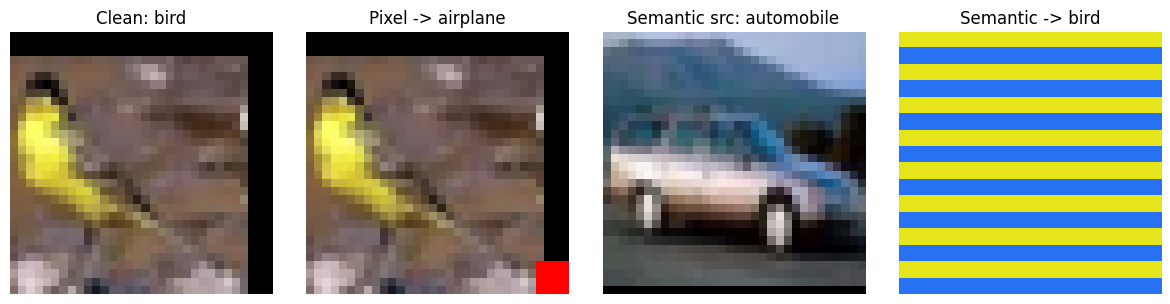

In [6]:
step_head, step_backbone, step_tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)
step_head = step_head.to(device)
step_backbone = step_backbone.to(device)
step_tail = step_tail.to(device)

head_opt = torch.optim.SGD(step_head.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)
backbone_opt = torch.optim.SGD(step_backbone.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)
tail_opt = torch.optim.SGD(step_tail.parameters(), lr=cfg.LR, momentum=cfg.MOMENTUM)

clean_inputs, clean_targets = next(iter(DataLoader(client_subsets[0], batch_size=8, shuffle=True, num_workers=0)))
clean_inputs = clean_inputs.to(device)
clean_targets = clean_targets.to(device)

head_opt.zero_grad()
backbone_opt.zero_grad()
tail_opt.zero_grad()

smashed = step_head(clean_inputs)
smashed_detached = smashed.detach().requires_grad_(True)
backbone_output = step_backbone(smashed_detached)
backbone_output_detached = backbone_output.detach().requires_grad_(True)
logits = step_tail(backbone_output_detached)
loss = torch.nn.functional.cross_entropy(logits, clean_targets)
loss.backward()
tail_opt.step()
backbone_output.backward(backbone_output_detached.grad)
backbone_opt.step()
smashed.backward(smashed_detached.grad)
head_opt.step()

clean_step_rows = [
    {"quantity": "loss", "value": float(loss.item())},
    {"quantity": "head grad norm", "value": float(torch.norm(smashed_detached.grad).item())},
    {"quantity": "backbone grad norm", "value": float(torch.norm(backbone_output_detached.grad).item())},
]
show_rows(clean_step_rows)

pixel_attack = PixelTriggerAttack(
    trigger_size=cfg.TRIGGER_SIZE,
    position=cfg.TRIGGER_POS,
    target_label=cfg.PIXEL_TARGET_LABEL,
)

clean_image, clean_label = client_subsets[0][0]
poisoned_image, poisoned_label = pixel_attack.poison_sample(clean_image, int(clean_label))
print(f"Pixel attack relabels {class_names[int(clean_label)]} -> {class_names[int(poisoned_label)]}")

semantic_attack = SemanticTriggerAttack(
    source_label=cfg.SEMANTIC_SOURCE_LABEL,
    target_label=cfg.SEMANTIC_TARGET_LABEL,
)
semantic_index = next(i for i, label in enumerate(train_dataset.targets) if label == cfg.SEMANTIC_SOURCE_LABEL)
semantic_image, semantic_label = train_dataset[semantic_index]
semantic_poisoned_image, semantic_poisoned_label = semantic_attack.poison_sample(semantic_image, int(semantic_label))
print(f"Semantic attack relabels {class_names[int(semantic_label)]} -> {class_names[int(semantic_poisoned_label)]}")


fig, axes = plt.subplots(1, 4, figsize=(12, 3))
visuals = [
    (clean_image, f"Clean: {class_names[int(clean_label)]}"),
    (poisoned_image, f"Pixel -> {class_names[int(poisoned_label)]}"),
    (semantic_image, f"Semantic src: {class_names[int(semantic_label)]}"),
    (semantic_poisoned_image, f"Semantic -> {class_names[int(semantic_poisoned_label)]}"),
]
for ax, (image, title) in zip(axes, visuals):
    ax.imshow(unnormalize(image).permute(1, 2, 0))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Compute BA And MA

The project keeps the evaluation separate from training. `MA` is the clean test accuracy, while `BA` is measured on a triggered test set where the attacker wants predictions to match the target label.

In [7]:
small_test = Subset(test_dataset, list(range(256)))
small_test_loader = DataLoader(small_test, batch_size=64, shuffle=False, num_workers=0)
small_trigger_set = pixel_attack.build_backdoor_test_set(small_test)

metric_head, metric_backbone, metric_tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)
metric_head = metric_head.to(device)
metric_backbone = metric_backbone.to(device)
metric_tail = metric_tail.to(device)

initial_ma = evaluate_model(metric_head, metric_backbone, metric_tail, small_test_loader, device)
initial_ba = evaluate_backdoor(metric_head, metric_backbone, metric_tail, small_trigger_set, device)
show_rows([
    {"metric": "MA", "value": round(initial_ma, 4)},
    {"metric": "BA", "value": round(initial_ba, 4)},
])


metric | value  
-------+--------
MA     | 10.1562
BA     | 99.6094


## Show SafeSplit Checkpoint History, DCT Score, Rotational Score, And Rollback Selection

SafeSplit analyzes the server-visible backbone after each client session. The implementation stores each checkpoint, computes a low-frequency DCT signature from the backbone update, computes a rotational signature from the current backbone state, scores both using the smallest-majority idea, and rolls back to the latest checkpoint that appears benign under both signals.

round | clean_ma | backdoor_ba | selected_step | selected_client
------+----------+-------------+---------------+----------------
1     | 13.28125 | 21.484375   | 4             | 3              
step | round | client | rollback_selected
-----+-------+--------+------------------
1    | 0     | 0      | False            
2    | 0     | 1      | False            
3    | 0     | 2      | False            
4    | 0     | 3      | True             
step | client | freq_score | rot_score | freq_majority | rot_majority | benign_intersection
-----+--------+------------+-----------+---------------+--------------+--------------------
1    | 0      | 1.169228   | 0.019287  | False         | False        | False              
2    | 1      | 0.721173   | 0.012807  | True          | True         | True               
3    | 2      | 0.721421   | 0.012834  | True          | True         | True               
4    | 3      | 1.015019   | 0.019212  | True          | True         | True               
S

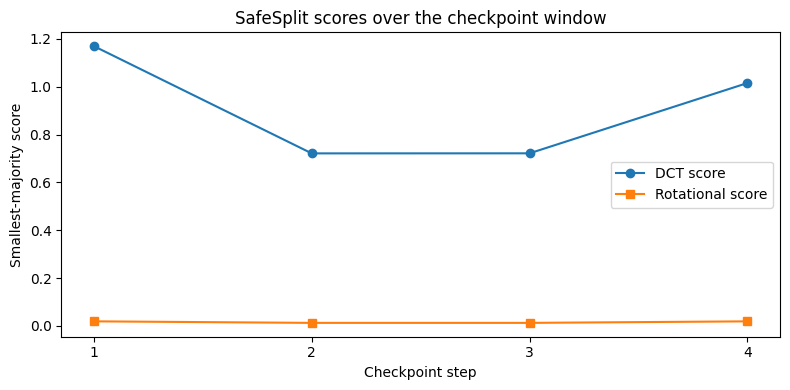

In [9]:
tiny_test = Subset(test_dataset, list(range(256)))
tiny_test_loader = DataLoader(tiny_test, batch_size=64, shuffle=False, num_workers=0)
tiny_trigger_set = pixel_attack.build_backdoor_test_set(tiny_test)

tiny_loaders = []
tiny_malicious_ids = {0}
for client_id, subset in enumerate(client_subsets):
    local_subset = Subset(train_dataset, subset.indices[:64])
    local_dataset = local_subset
    if client_id in tiny_malicious_ids:
        local_dataset = PoisonedDataset(local_subset, pixel_attack, poisoned_data_rate=0.5, seed=NOTEBOOK_SEED + client_id)
    tiny_loaders.append(DataLoader(local_dataset, batch_size=32, shuffle=True, num_workers=0))

tiny_head, tiny_backbone, tiny_tail = get_split_model("simple_cnn", cfg.NUM_CLASSES)
tiny_defense = SafeSplitDefense(window_size=note_num_clients, low_freq_frac=cfg.DCT_LOW_FREQ_FRAC, matrix_width=cfg.ROTATION_MATRIX_WIDTH)
tiny_trainer = SplitLearningTrainer(
    head0=tiny_head,
    backbone0=tiny_backbone,
    tail0=tiny_tail,
    client_loaders=tiny_loaders,
    device=device,
    lr=cfg.LR,
    momentum=cfg.MOMENTUM,
    weight_decay=cfg.WEIGHT_DECAY,
    local_epochs=1,
    defense=tiny_defense,
)

tiny_history = tiny_trainer.run(num_rounds=1, test_loader=tiny_test_loader, trigger_set=tiny_trigger_set)
show_rows(tiny_history)

checkpoint_rows = []
for checkpoint in tiny_trainer.history:
    checkpoint_rows.append(
        {
            "step": checkpoint.step,
            "round": checkpoint.round_id,
            "client": checkpoint.client_id,
            "rollback_selected": checkpoint.step == tiny_trainer.last_selected_checkpoint.step,
        }
    )
show_rows(checkpoint_rows)

window = tiny_trainer.history[-note_num_clients:]
majority_size = note_num_clients // 2 + 1
freq_signatures = [dct_low_frequency(flatten_state_dict(cp.update_state), cfg.ROTATION_MATRIX_WIDTH, cfg.DCT_LOW_FREQ_FRAC) for cp in window]
rot_signatures = [rotational_signature(flatten_state_dict(cp.backbone_state), cfg.ROTATION_MATRIX_WIDTH) for cp in window]

frequency_scores = []
rotation_scores = []
for i in range(len(window)):
    freq_distances = []
    rot_distances = []
    for j in range(len(window)):
        if i == j:
            continue
        freq_distances.append(torch.dist(freq_signatures[i], freq_signatures[j], p=2).item())
        rot_distances.append(torch.mean(torch.abs(rot_signatures[i] - rot_signatures[j])).item())
    frequency_scores.append(smallest_majority_sum(freq_distances, majority_size))
    rotation_scores.append(smallest_majority_sum(rot_distances, majority_size))

frequency_majority = set(sorted(range(len(window)), key=lambda idx: frequency_scores[idx])[:majority_size])
rotation_majority = set(sorted(range(len(window)), key=lambda idx: rotation_scores[idx])[:majority_size])
benign_indices = frequency_majority.intersection(rotation_majority)

score_rows = []
for idx, checkpoint in enumerate(window):
    score_rows.append(
        {
            "step": checkpoint.step,
            "client": checkpoint.client_id,
            "freq_score": round(frequency_scores[idx], 6),
            "rot_score": round(rotation_scores[idx], 6),
            "freq_majority": idx in frequency_majority,
            "rot_majority": idx in rotation_majority,
            "benign_intersection": idx in benign_indices,
        }
    )
show_rows(score_rows)

print(
    "Selected rollback checkpoint:",
    {
        "step": tiny_trainer.last_selected_checkpoint.step,
        "client": tiny_trainer.last_selected_checkpoint.client_id,
        "round": tiny_trainer.last_selected_checkpoint.round_id,
    },
)


steps = [checkpoint.step for checkpoint in window]
plt.figure(figsize=(8, 4))
plt.plot(steps, frequency_scores, marker="o", label="DCT score")
plt.plot(steps, rotation_scores, marker="s", label="Rotational score")
plt.xlabel("Checkpoint step")
plt.ylabel("Smallest-majority score")
plt.title("SafeSplit scores over the checkpoint window")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend()
plt.tight_layout()
plt.show()

## Run Real Experiments In The Notebook

The earlier sections are still the walkthrough layer. The cells below turn this notebook into the main experiment interface.

Use the shared preset system instead of editing tiny hard-coded values by hand:
- `lite`: fastest feedback
- `medium`: more informative but still notebook-friendly
- `paper`: paper-like midterm configuration

These cells call the same in-process runner used by the CLI, so notebook and script results now come from the same code path.

In [8]:
NOTEBOOK_EXPERIMENT_PRESET = "paper"
NOTEBOOK_SAVE_JSON = False

preset_rows = []
for preset_name in ("lite", "medium", "paper"):
    preset_cfg = cfg.resolve_preset(preset_name)
    preset_rows.append(
        {
            "preset": preset_name,
            "arch": preset_cfg["arch"],
            "rounds": preset_cfg["num_rounds"],
            "clients": preset_cfg["num_clients"],
            "malicious": preset_cfg["num_malicious"],
            "max_samples_per_client": preset_cfg["max_samples_per_client"],
            "local_epochs": preset_cfg["local_epochs"],
            "batch_size": preset_cfg["batch_size"],
            "eval_batch_size": preset_cfg["eval_batch_size"],
        }
    )
show_rows(preset_rows)


def notebook_request(**overrides):
    return build_experiment_request(
        preset=NOTEBOOK_EXPERIMENT_PRESET,
        seed=NOTEBOOK_SEED,
        device=device,
        write_json=NOTEBOOK_SAVE_JSON,
        **overrides,
    )


def run_notebook_experiment(label: str, **overrides):
    request = notebook_request(**overrides)
    result = run_experiment(request)
    row = {"label": label, **result_to_row(result)}
    return result, row


def summarize_history(result: dict[str, object]) -> None:
    history_rows = []
    for item in result["history"]:
        history_rows.append(
            {
                "round": item["round"],
                "clean_ma": round(float(item["clean_ma"]), 4),
                "backdoor_ba": round(float(item["backdoor_ba"]), 4),
                "selected_step": item["selected_step"],
                "selected_client": item["selected_client"],
            }
        )
    show_rows(history_rows)


single_result, single_row = run_notebook_experiment(
    label="single-run-demo",
    defense="safesplit",
    backdoor="semantic",
)
show_rows([single_row])
summarize_history(single_result)

preset | arch       | rounds | clients | malicious | max_samples_per_client | local_epochs | batch_size | eval_batch_size
-------+------------+--------+---------+-----------+------------------------+--------------+------------+----------------
lite   | simple_cnn | 1      | 4       | 1         | 256                    | 1            | 64         | 128            
medium | resnet18   | 2      | 6       | 1         | 1024                   | 1            | 96         | 128            
paper  | resnet18   | 5      | 10      | 2         | None                   | 1            | 128        | 256            
label           | preset | arch     | defense   | backdoor | iid_rate | rounds | clients | malicious | final_MA | final_BA | results_path
----------------+--------+----------+-----------+----------+----------+--------+---------+-----------+----------+----------+-------------
single-run-demo | paper  | resnet18 | safesplit | semantic | 0.8      | 5      | 10      | 2         | 39.68    | 

## Midterm Comparison Suites

The next cell runs the same proposal-focused comparisons directly in the notebook:
- Table II subset: pixel and semantic, with and without SafeSplit
- Table III subset: semantic attack across IID rates `0.6`, `0.8`, `1.0`
- Reduced baseline panel at IID `0.6`

Set `NOTEBOOK_EXPERIMENT_PRESET` in the previous cell to `lite`, `medium`, or `paper` depending on how quickly you want results.

Table II subset (paper preset)
label                       | preset | arch     | defense   | backdoor | iid_rate | rounds | clients | malicious | final_MA | final_BA | results_path
----------------------------+--------+----------+-----------+----------+----------+--------+---------+-----------+----------+----------+-------------
table-ii-semantic-none      | paper  | resnet18 | none      | semantic | 0.8      | 5      | 10      | 2         | 51.24    | 100.0    | None        
table-ii-semantic-safesplit | paper  | resnet18 | safesplit | semantic | 0.8      | 5      | 10      | 2         | 39.37    | 0.0      | None        
table-ii-pixel-none         | paper  | resnet18 | none      | pixel    | 0.8      | 5      | 10      | 2         | 48.54    | 99.99    | None        
table-ii-pixel-safesplit    | paper  | resnet18 | safesplit | pixel    | 0.8      | 5      | 10      | 2         | 39.55    | 6.62     | None        


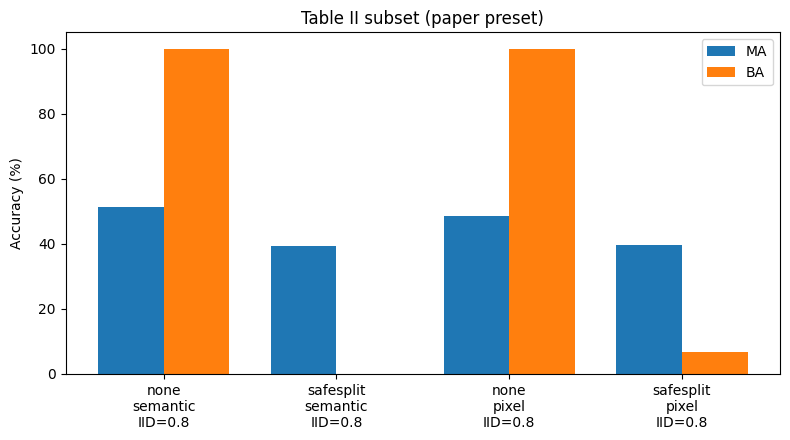

Table III subset (paper preset)
label                       | preset | arch     | defense   | backdoor | iid_rate | rounds | clients | malicious | final_MA | final_BA | results_path
----------------------------+--------+----------+-----------+----------+----------+--------+---------+-----------+----------+----------+-------------
table-iii-iid-0.6-none      | paper  | resnet18 | none      | semantic | 0.6      | 5      | 10      | 2         | 43.68    | 100.0    | None        
table-iii-iid-0.6-safesplit | paper  | resnet18 | safesplit | semantic | 0.6      | 5      | 10      | 2         | 37.22    | 0.0      | None        
table-iii-iid-0.8-none      | paper  | resnet18 | none      | semantic | 0.8      | 5      | 10      | 2         | 50.29    | 100.0    | None        
table-iii-iid-0.8-safesplit | paper  | resnet18 | safesplit | semantic | 0.8      | 5      | 10      | 2         | 39.76    | 0.0      | None        
table-iii-iid-1.0-none      | paper  | resnet18 | none      | semant

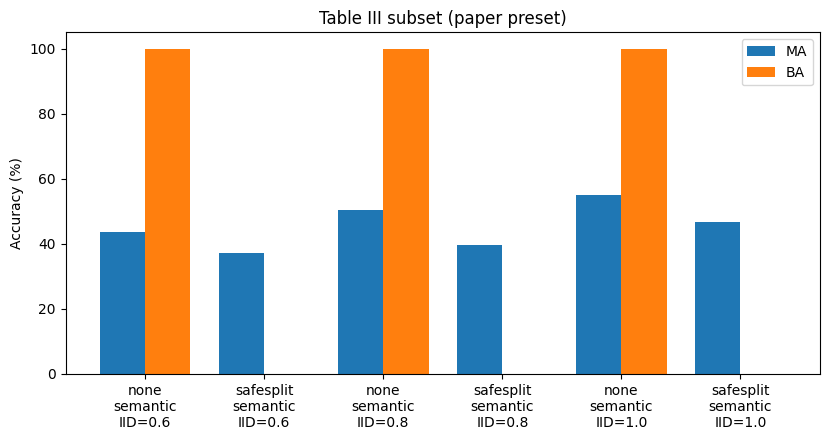

Reduced baseline panel (paper preset)
label                      | preset | arch     | defense   | backdoor | iid_rate | rounds | clients | malicious | final_MA | final_BA | results_path
---------------------------+--------+----------+-----------+----------+----------+--------+---------+-----------+----------+----------+-------------
baseline-iid-0.6-none      | paper  | resnet18 | none      | semantic | 0.6      | 5      | 10      | 2         | 43.34    | 100.0    | None        
baseline-iid-0.6-dp        | paper  | resnet18 | dp        | semantic | 0.6      | 5      | 10      | 2         | 11.33    | 100.0    | None        
baseline-iid-0.6-krum      | paper  | resnet18 | krum      | semantic | 0.6      | 5      | 10      | 2         | 31.85    | 0.0      | None        
baseline-iid-0.6-safesplit | paper  | resnet18 | safesplit | semantic | 0.6      | 5      | 10      | 2         | 36.5     | 0.0      | None        


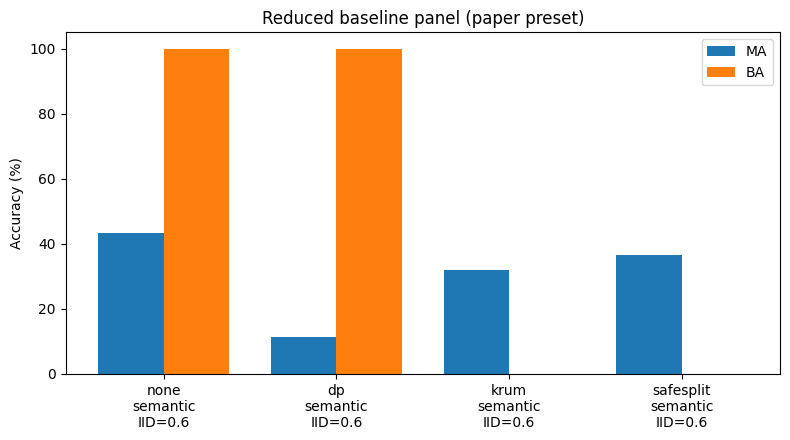

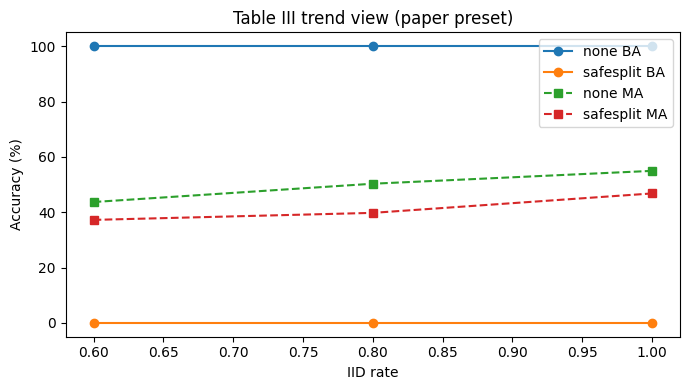

label                       | takeaway                                  | MA    | BA   
----------------------------+-------------------------------------------+-------+------
table-ii-semantic-none      | No defense is expected to allow higher BA | 51.24 | 100.0
table-ii-semantic-safesplit | SafeSplit suppresses BA                   | 39.37 | 0.0  
table-ii-pixel-none         | No defense is expected to allow higher BA | 48.54 | 99.99
table-ii-pixel-safesplit    | SafeSplit suppresses BA                   | 39.55 | 6.62 


In [ ]:
TABLE_II_CASES = [
    ("table-ii-semantic-none", {"backdoor": "semantic", "defense": "none"}),
    ("table-ii-semantic-safesplit", {"backdoor": "semantic", "defense": "safesplit"}),
    ("table-ii-pixel-none", {"backdoor": "pixel", "defense": "none"}),
    ("table-ii-pixel-safesplit", {"backdoor": "pixel", "defense": "safesplit"}),
]
TABLE_III_CASES = [
    (f"table-iii-iid-{iid}-{defense}", {"backdoor": "semantic", "defense": defense, "iid_rate": iid})
    for iid in (0.6, 0.8, 1.0)
    for defense in ("none", "safesplit")
]
BASELINE_CASES = [
    (f"baseline-iid-0.6-{defense}", {"backdoor": "semantic", "defense": defense, "iid_rate": 0.6})
    for defense in ("none", "dp", "krum", "safesplit")
]


def run_case_group(cases, title: str):
    rows = []
    for label, overrides in cases:
        _, row = run_notebook_experiment(label=label, **overrides)
        rows.append(row)
    print(title)
    show_rows(rows, max_rows=len(rows))
    plot_metric_summary(rows, title)
    return rows


table_ii_rows = run_case_group(TABLE_II_CASES, f"Table II subset ({NOTEBOOK_EXPERIMENT_PRESET} preset)")
table_iii_rows = run_case_group(TABLE_III_CASES, f"Table III subset ({NOTEBOOK_EXPERIMENT_PRESET} preset)")
baseline_rows = run_case_group(BASELINE_CASES, f"Reduced baseline panel ({NOTEBOOK_EXPERIMENT_PRESET} preset)")


safe_rows = [row for row in table_iii_rows if row["defense"] == "safesplit"]
none_rows = [row for row in table_iii_rows if row["defense"] == "none"]
safe_rows = sorted(safe_rows, key=lambda row: row["iid_rate"])
none_rows = sorted(none_rows, key=lambda row: row["iid_rate"])
plt.figure(figsize=(7, 4))
plt.plot([row["iid_rate"] for row in none_rows], [row["final_BA"] for row in none_rows], marker="o", label="none BA")
plt.plot([row["iid_rate"] for row in safe_rows], [row["final_BA"] for row in safe_rows], marker="o", label="safesplit BA")
plt.plot([row["iid_rate"] for row in none_rows], [row["final_MA"] for row in none_rows], marker="s", linestyle="--", label="none MA")
plt.plot([row["iid_rate"] for row in safe_rows], [row["final_MA"] for row in safe_rows], marker="s", linestyle="--", label="safesplit MA")
plt.xlabel("IID rate")
plt.ylabel("Accuracy (%)")
plt.title(f"Table III trend view ({NOTEBOOK_EXPERIMENT_PRESET} preset)")
plt.legend()
plt.tight_layout()
plt.show()


interpretation_rows = []
for row in table_ii_rows:
    interpretation_rows.append(
        {
            "label": row["label"],
            "takeaway": "SafeSplit suppresses BA" if row["defense"] == "safesplit" else "No defense is expected to allow higher BA",
            "MA": row["final_MA"],
            "BA": row["final_BA"],
        }
    )
show_rows(interpretation_rows, max_rows=len(interpretation_rows))

## Run One Small End-To-End Example

The final cell compares a tiny no-defense run against a tiny SafeSplit run. These numbers are not meant to exactly match the paper. They are a compact sanity check that the code path is wired correctly and that the qualitative direction of the defense can be inspected in one notebook session.

defense   | final_MA | final_BA | selected_step
----------+----------+----------+--------------
none      | 7.8125   | 0.0      | 4            
safesplit | 9.7656   | 69.5312  | 4            


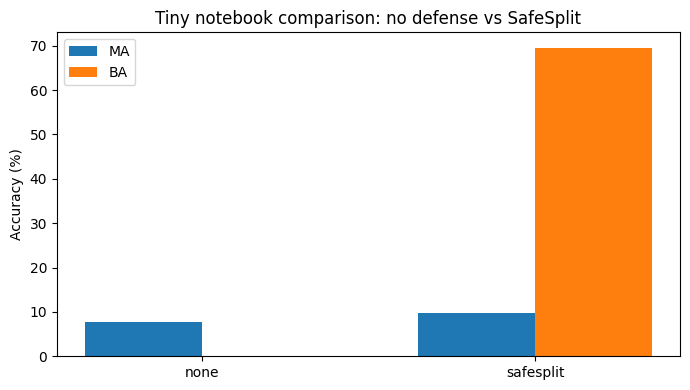

In [10]:
def build_tiny_client_loaders(attack=None):
    loaders = []
    malicious_ids = {0} if attack is not None else set()
    for client_id, subset in enumerate(client_subsets):
        local_subset = Subset(train_dataset, subset.indices[:64])
        local_dataset = local_subset
        if client_id in malicious_ids and attack is not None:
            local_dataset = PoisonedDataset(local_subset, attack, poisoned_data_rate=0.5, seed=NOTEBOOK_SEED + 100 + client_id)
        loaders.append(DataLoader(local_dataset, batch_size=32, shuffle=True, num_workers=0))
    return loaders


def run_tiny_experiment(defense_name: str):
    attack = PixelTriggerAttack(trigger_size=cfg.TRIGGER_SIZE, position=cfg.TRIGGER_POS, target_label=cfg.PIXEL_TARGET_LABEL)
    loaders = build_tiny_client_loaders(attack=attack)
    head0, backbone0, tail0 = get_split_model("simple_cnn", cfg.NUM_CLASSES)
    defense = None
    if defense_name == "safesplit":
        defense = SafeSplitDefense(
            window_size=note_num_clients,
            low_freq_frac=cfg.DCT_LOW_FREQ_FRAC,
            matrix_width=cfg.ROTATION_MATRIX_WIDTH,
        )
    trainer = SplitLearningTrainer(
        head0=head0,
        backbone0=backbone0,
        tail0=tail0,
        client_loaders=loaders,
        device=device,
        lr=cfg.LR,
        momentum=cfg.MOMENTUM,
        weight_decay=cfg.WEIGHT_DECAY,
        local_epochs=1,
        defense=defense,
    )
    trigger_set = attack.build_backdoor_test_set(tiny_test)
    history = trainer.run(num_rounds=1, test_loader=tiny_test_loader, trigger_set=trigger_set)
    return {
        "defense": defense_name,
        "final_MA": round(history[-1]["clean_ma"], 4),
        "final_BA": round(history[-1]["backdoor_ba"], 4),
        "selected_step": history[-1]["selected_step"],
    }


comparison_rows = [run_tiny_experiment("none"), run_tiny_experiment("safesplit")]
show_rows(comparison_rows)

if HAS_MPL:
    labels = [row["defense"] for row in comparison_rows]
    ma_values = [row["final_MA"] for row in comparison_rows]
    ba_values = [row["final_BA"] for row in comparison_rows]
    x = np.arange(len(labels))
    width = 0.35
    plt.figure(figsize=(7, 4))
    plt.bar(x - width / 2, ma_values, width, label="MA")
    plt.bar(x + width / 2, ba_values, width, label="BA")
    plt.xticks(x, labels)
    plt.ylabel("Accuracy (%)")
    plt.title("Tiny notebook comparison: no defense vs SafeSplit")
    plt.legend()
    plt.tight_layout()
    plt.show()
